In [13]:
import numpy as np
import matplotlib.pyplot as plt
import astropy
from astropy.cosmology import Planck15
import astropy.cosmology as cosmo
import astropy.units as u
from scipy.optimize import minimize
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
from scipy import integrate
import pandas as pd
plt.style.use(['science','grid','notebook'])
from tqdm import tqdm
color_map='YlGnBu'

In [14]:
### writing the functions for various order assuming Omega_k=0
def z_series_1(z, H0):

    a0 = 1.0
    
    return 300000 * z / H0 * a0
def z_series_2(z, H0, q0):

    a0 = 1.0
    a1 = 1.0/2.0 - q0/2.0
    
    return 300000 * z / H0 * (a0 + a1*z )

def z_series_3(z, H0, q0, j0):

    a0 = 1.0
    a1 = 1.0/2.0 - q0/2.0
    a2 = -1.0/6.0 - j0/6.0 + q0/6.0 + q0**2.0 / 2.0
    
    return 300000 * z / H0 * (a0 + a1*z + a2 * z**2.0)

def z_series_4(z, H0, q0, j0, s0):

    a0 = 1.0
    a1 = 1.0/2.0 - q0/2.0
    a2 = -1.0/6.0 - j0/6.0 + q0/6.0 + q0**2.0 / 2.0
    a3 = 1.0/12.0 + 5 * j0 / 24.0 - q0/12.0 + 5.0*j0*q0/12.0  -5.0 * q0**2.0 / 8.0  -5.0 * q0**3.0 / 8.0 + s0/24.0

    return 300000 * z / H0 * (a0 + a1*z + a2 * z**2.0 + a3 * z**3.0)

def z_series_4(z, H0, q0, j0, s0):

    a0 = 1.0
    a1 = 1.0/2.0 - q0/2.0
    a2 = -1.0/6.0 - j0/6.0 + q0/6.0 + q0**2.0 / 2.0
    a3 = 1.0/12.0 + 5 * j0 / 24.0 - q0/12.0 + 5.0*j0*q0/12.0  -5.0 * q0**2.0 / 8.0  -5.0 * q0**3.0 / 8.0 + s0/24.0

    return 300000 * z / H0 * (a0 + a1*z + a2 * z**2.0 + a3 * z**3.0)

def z_series5( z,H0,q0, j0,s0,l0):
        a0 = 1.0
        a1 = 1.0/2.0 - q0/2.0
        a2 = -1.0/6.0 - j0/6.0 + q0/6.0 + q0**2.0 / 2.0
        a3 = 1.0/12.0 + 5 * j0 / 24.0 - q0/12.0 + 5.0*j0*q0/12.0  -5.0 * q0**2.0 / 8.0  -5.0 * q0**3.0 / 8.0 + s0/24.0
        a4 = - 1.0/20.0 -9.0*j0/40+(j0**2)/12-l0/120+q0/20-(11*j0*q0)/12+27*q0**2/40-(7*j0*q0**2)/8+11*(q0**3)/8+(7*q0**4)/8-(11*s0)/120-q0*s0/8
        return 300000 * z / H0 * (a0 + a1*z + a2 * z**2.0 + a3 * z**3.0+ a4 * z**4.0)

def z_series_5(z,  H0,q0, j0, s0, c0, k=0, a0=1):
    # Define the constants
    k= 0  # Curvature constant

    # Compute each term in the series expansion
    a1 = 1 + (1/2) * (1 - q0) 
    a2 = (1/6) * ((-k/(a0**2 * H0**2)) - j0 + 3 * q0**2 + q0 - 1) 
    a3 = (1/24) * ((6 * q0 + 2) * k/(a0**2 * H0**2) + 5 * j0 * (2 * q0 + 1) - 15 * q0**3 - 15 * q0**2 - 2 * q0 + s0 + 2) 
    a4 = (1/120) * (10 * q0**2 - j0 * (105 * q0 + 27) - c0 + 105 * q0**4 + 165 * q0**3 + 81 * q0**2 - 15 * q0 * s0 + 6 * q0 - 11 * s0 - 6 + (5 * k/(a0**2 * H0**2)) * (2 * j0 - 9 * q0**2 - 8 * q0 - 1) + 1/(a0**4 * H0**4)) 

    # Calculate d_L(z)
    
    return 300000 * z / H0 * (a0 + a1*z + a2 * z**2.0 + a3 * z**3.0+ a4 * z**4.0)
    
def logz_1(log1z,H0):

    a0p = 1.0

    return 300000 * log1z / H0 * (a0p)

def logz_2(log1z,H0,q0):
    a0p = 1.0
    a1p = 1 -1/2*q0

    return 300000 * log1z / H0 * (a0p + a1p*log1z)

def logz_3(log1z,H0,q0,j0):
    
        a0p = 1.0
        a1p = 1 -1/2*q0
        a2p = 1/6 * (3-2*q0+3*q0**2-j0)
    
        return 300000 * log1z / H0 * (a0p + a1p*log1z + a2p * log1z**2.0)

def logz_4(log1z,H0,q0,j0,s0):

    a0p = 1.0
    a1p = 1 -1/2*q0
    a2p = 1/6 * (3-2*q0+3*q0**2-j0)
    a3p =  1/6 +(1/8)*(-q0 + q0**2 -5*q0**3) +(5/12)*q0*j0 + 1/24*(-j0 + s0)

    #return redshift_expansion(z, H0, a0, a1, a2, a3, order)
    return 300000 * log1z / H0 * (a0p + a1p*log1z + a2p * log1z**2.0 + a3p * log1z**3.0)
     
     



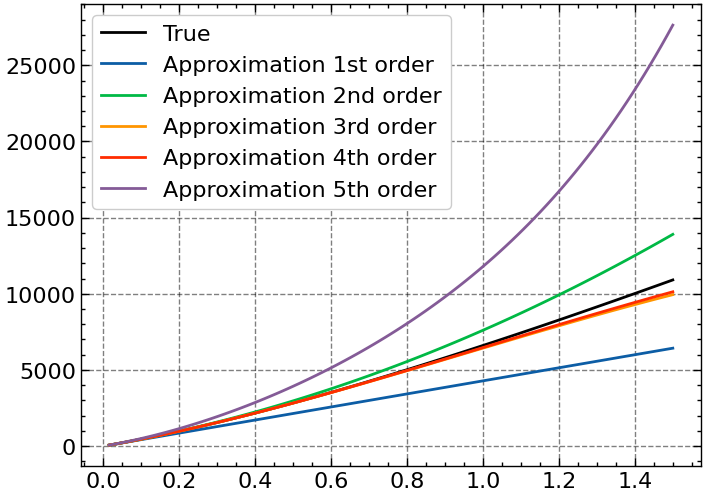

In [15]:
my_cosmo = cosmo.wCDM(H0=70, Om0=0.3, Ode0=0.7)

zs = np.linspace(0.0, 1.5, 100)
zs = zs[1:] # We don't want z = 0
logzs= np.log(1+zs)
dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value
plt.plot(zs, dls_true, label='True',color='k')
plt.plot(zs,z_series_1(zs,70), label='Approximation 1st order')
plt.plot(zs,z_series_2(zs,70,-0.55), label='Approximation 2nd order')
plt.plot(zs,z_series_3(zs,70,-0.55,1), label='Approximation 3rd order')
plt.plot(zs,z_series_4(zs,70,-0.55,1,-0.35), label='Approximation 4th order')

plt.plot(zs,z_series_5(zs,70,-0.55,1,-0.35,3.11), label='Approximation 5th order')

plt.legend()

In [16]:
def chi_square_z(theta, z, data,func):
    
    diff = func(z, *theta) - data
    return np.sum(diff*diff)

func_array_z=np.array([eval(f'z_series_{i}') for i in range(1,6)])
func_array_logz=np.array([eval(f'logz_{i}') for i in range(1,5)])

N=10    
ZMAX=2   #highest redshift to which we need to go
z_max_array=np.linspace(0.1,ZMAX,N)  #creates an array from 0.1 to ZMAX with N elements
X_z,Y_z=np.meshgrid(func_array_z,z_max_array)  #creates an square array with every possible combination of function and ZMAX
x1_z=np.reshape(X_z,(1,5*N))[0]## flattening the square matrices
y1_z=np.reshape(Y_z,(1,5*N))[0] 

X_logz,Y_logz=np.meshgrid(func_array_z,z_max_array)  #creates an square array with every possible combination of function and ZMAX
x1_logz=np.reshape(X_z,(1,5*N))[0]## flattening the square matrices
y1_logz=np.reshape(Y_z,(1,5*N))[0]

priors = {
    'z_series_1': [70],
    'z_series_2': [70, -0.55],
    'z_series_3': [70, -0.55, 1],
    'z_series_4': [70, -0.55, 1, -0.35],
    'z_series_5': [70, -0.55, 1, -0.35, -3.11]
    
} #setting priors for every function

In [17]:
Ok = 0.0
w = -1.0

my_cosmo = cosmo.wCDM(H0=70, Om0=0.3, Ode0=1.0-0.3-Ok)

In [18]:
func_name

'z_series_5'

In [19]:
def kinematic_parameter_estimator(series_expansion):
    N=10    
    ZMAX=2 #highest redshift to which we need to go
    z_max_array=np.linspace(0.1,ZMAX,N)  #creates an array from 0.1 to ZMAX with N elements
    if series_expansion == 'z_series':
        func_array=[eval(f'z_series_{i}') for i in range(1,5)]
        priors = {
        'z_series_1': [70],
        'z_series_2': [70, -0.55],
        'z_series_3': [70, -0.55, 1],
        'z_series_4': [70, -0.55, 1, -0.35],
        'z_series_5': [70, -0.55, 1, -0.35, -3.11]
    
         } #setting priors for every function
    elif series_expansion == 'logz':
        func_array=[eval(f'logz_{i}') for i in range(1,5)]
        priors = {
        'logz_1': [70],
        'logz_2': [70, -0.55],
        'logz_3': [70, -0.55, 1],
        'logz_4': [70, -0.55, 1, -0.35]} #setting priors for every function
    else:
        print('Please enter a valid series expansion')
        return None
    
    func_name_list=[func.__name__ for func in func_array]
    
    X,Y=np.meshgrid(func_array,z_max_array) 
    x1=np.reshape(X,(1,len(func_name_list)*N))[0]## flattening the square matrices
    y1=np.reshape(Y,(1,len(func_name_list)*N))[0] 
    
    res=[]   #creating  empty arrays to append results
    stat=[]
    func_name_array=[]
    for func,z_max in list(zip(x1,y1)):
        zs = np.linspace(0.00, z_max, 100)  
        func_name = func.__name__ ##extracting function name
        zs = zs[1:]
        logzs= np.log(1+zs)
        #print(func_name)
        initial_priors = priors[func_name]
        dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value
        if series_expansion == 'z_series':
            result = minimize(chi_square_z, initial_priors,args=(zs, dls_true,func), method='L-BFGS-B', options={'maxiter':950000})
        elif series_expansion == 'logz':
            result = minimize(chi_square_z, initial_priors,args=(logzs, dls_true,func), method='L-BFGS-B', options={'maxiter':950000})
        res.append(result.x)    ##appending results in the emtpy array
        stat.append(result.success)
    func_name=[i.__name__ for i in np.array(list(zip(x1,y1)))[:,0]]
    dct={'func':func_name,'zmax':np.array(list(zip(x1,y1)))[:,1],'Output':res,"success":stat}

    df=pd.DataFrame(dct)
    return df


In [20]:
# to be added later for n simuations and then taking an average
'''##initializing the values for the simulations
num_sim=10 # number of simulations 

H0 =  np.random.uniform(60,80,num_sim)
Om = np.random.uniform(0,0.5,num_sim)
Ok = 0.0
w = -1.0
sim_num=[]
res=[]   #creating  empty arrays to append results
stat=[]
func_name_array=[]
for n in tqdm(range(num_sim)):
    my_cosmo = cosmo.wCDM(H0=H0[n], Om0=Om[n], Ode0=1.0-Om[n]-Ok)
    for func,z_max in list(zip(x1,y1)):
        zs = np.linspace(0.00, z_max, 100)  
        func_name = func.__name__ ##extracting function name 
        zs = zs[1:] # We don't want z = 0
        initial_priors = priors[func_name]  #getting corresponding prior
    
        dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value ##getting true luminosity distance
        #print(func_name,z_max)
        result = minimize(chi_square_z, initial_priors,args=(zs, dls_true,func), method='L-BFGS-B', options={'maxiter':950000})
        res.append(result.x)    ##appending results in the emtpy array
        stat.append(result.success)  ## seeing if i get succes in minimization
        #func_name=func_name_array.append(*[i.__name__ for i in np.array(list(zip(x1,y1)))[:,0]])
        sim_num.append(np.ones(100)*n)

dct={'# simuation':sim_num,'zmax':np.array(list(zip(x1,y1)))[:,1],'Output':res,"success":stat}'''


'##initializing the values for the simulations\nnum_sim=10 # number of simulations \n\nH0 =  np.random.uniform(60,80,num_sim)\nOm = np.random.uniform(0,0.5,num_sim)\nOk = 0.0\nw = -1.0\nsim_num=[]\nres=[]   #creating  empty arrays to append results\nstat=[]\nfunc_name_array=[]\nfor n in tqdm(range(num_sim)):\n    my_cosmo = cosmo.wCDM(H0=H0[n], Om0=Om[n], Ode0=1.0-Om[n]-Ok)\n    for func,z_max in list(zip(x1,y1)):\n        zs = np.linspace(0.00, z_max, 100)  \n        func_name = func.__name__ ##extracting function name \n        zs = zs[1:] # We don\'t want z = 0\n        initial_priors = priors[func_name]  #getting corresponding prior\n    \n        dls_true = my_cosmo.luminosity_distance(zs).to(u.Mpc).value ##getting true luminosity distance\n        #print(func_name,z_max)\n        result = minimize(chi_square_z, initial_priors,args=(zs, dls_true,func), method=\'L-BFGS-B\', options={\'maxiter\':950000})\n        res.append(result.x)    ##appending results in the emtpy array\n      

In [21]:
def value_extractor(df):
    H0_ar=[]
    for i in df.Output:
        H0_ar.append(i[0])
    q0_ar=[]
    ix=0
    for j in df.Output :
        
        if '1' not in df.func.iloc[ix]:
            
            q0_ar.append(j[1])
        ix+=1 
    j0_ar=[]
    ix=0
    for k in df.Output :
        if '1' not in df.func.iloc[ix] and '2' not in  df.func.iloc[ix]:

            j0_ar.append(k[2])

        ix+=1
    dim=int(len(H0_ar)/N)
    H0_ar=np.reshape(H0_ar,(N,dim)) ##first reshaping the arrays to get Nx5 matrix since we want our results in a matrix form
    H0_err=abs((73.8-H0_ar)/73.8)*100
    H0_err=np.flip(H0_err, axis=0)  ##flipping the array due to visualization
    q0_ar=np.reshape(q0_ar,(N,dim-1))
    q0_err=abs((0.55+q0_ar)/0.55)*100
    q0_err=np.flip(q0_err, axis=0)

    j0_ar=np.reshape(j0_ar,(N,dim-2))
    j0_err=abs((1-j0_ar)/1)*100
    j0_err=np.flip(j0_err, axis=0)
    return H0_err,q0_err,j0_err
print(value_extractor(kinematic_parameter_estimator('logz')))
print(value_extractor(kinematic_parameter_estimator('z_series')))




(array([[64.65547424, 64.52844767,  7.91121503,  4.17048747],
       [62.45982335, 48.29464634,  7.12365268,  5.45445568],
       [59.90754275, 35.50701831,  6.48149035,  5.26593497],
       [56.89843827, 25.24286358,  5.98411316,  4.85966706],
       [53.29086945, 16.90064642,  5.62379378,  5.05337995],
       [48.87857575, 10.08509598,  5.38318993,  5.02326231],
       [43.35085178,  4.54840543,  5.23618707,  5.08334709],
       [36.22103578,  0.16991905,  5.15195532,  5.08845452],
       [26.69118348,  3.03153775,  5.10472669,  5.08501923],
       [13.37789582,  4.84402035,  5.08458492,  5.08380496]]), array([[1.06774666e+03, 6.27340923e+01, 2.93238660e+01],
       [8.64133754e+02, 4.83718516e+01, 3.98200777e+00],
       [7.00003937e+02, 3.59439703e+01, 1.49275792e+00],
       [5.64082458e+02, 2.56176975e+01, 8.42291454e+00],
       [4.48759483e+02, 1.74735726e+01, 1.70352983e+00],
       [3.48648550e+02, 1.14255590e+01, 2.25252929e+00],
       [2.59754430e+02, 7.17902752e+00, 2.578

In [24]:
def matrix_plot(title,H0_err,q0_err,j0_err):
    plt.figure(figsize=(15,10))
    plt.title('$H_0$ variation '+str(title))
    norm = mcolors.LogNorm(vmin=H0_err[H0_err > 0].min(), vmax=H0_err.max()) #W#creating color bar for log plot
    plt.imshow(H0_err,norm=norm,cmap=color_map) ##matrix plot 
    y_ticks=[i for i in range(int(N))]
    y_labels=np.round(np.linspace(ZMAX,0.1,int(N)),1)
    x_ticks = [0, 1, 2, 3] 
    plt.ylabel('$z_{max}$',fontsize=15)
    
    x_labels = ['$\mathcal{O}(1)$', '$\mathcal{O}(2)$', '$\mathcal{O}(3)$', '$\mathcal{O}(4)$'] 
    plt.xticks(x_ticks, x_labels, rotation ='vertical') 
    plt.yticks(y_ticks, y_labels) 
    plt.colorbar(label='% deviation')
    ## for annotating on the plot
    for i in range(H0_err.shape[0]):
        for j in range(H0_err.shape[1]):
            text = plt.text(j, i, f'{H0_err[i, j]:.1f} %',
                        ha="center", va="center", color="white",path_effects=[path_effects.withStroke(linewidth=1.5, foreground="black")],fontsize=10)

    plt.show() 

    plt.figure(figsize=(15,10))
    plt.title('$q_0$ variation '+str(title))
    norm = mcolors.LogNorm(vmin=q0_err[q0_err > 0].min(), vmax=q0_err.max())

    plt.imshow(q0_err,cmap=color_map,norm=norm)
    y_ticks=[i for i in range(int(N))]
    y_labels=np.round(np.linspace(ZMAX,0.1,int(N)),1)
    x_ticks = [0, 1, 2] 
    plt.ylabel('$z_{max}$',fontsize=15)
    plt.xlabel('Taylor expansion order')
    x_labels = [ '$\mathcal{O}(2)$', '$\mathcal{O}(3)$', '$\mathcal{O}(4)$'] 
    plt.xticks(x_ticks, x_labels, rotation ='vertical') 
    plt.yticks(y_ticks, y_labels) 
    for i in range(q0_err.shape[0]):
        for j in range(q0_err.shape[1]):
            text = plt.text(j, i, f'{q0_err[i, j]:.1f} %',
                        ha="center", va="center", color="white",path_effects=[path_effects.withStroke(linewidth=1.5, foreground="black")],fontsize=10)

    #v = np.linspace(0, 100, 10, endpoint=True)

    plt.colorbar(label='% deviation')
    plt.show()

    plt.figure(figsize=(15,10))
    plt.title('$j_0$ variation '+str(title))
    norm = mcolors.LogNorm(vmin=j0_err[j0_err > 0].min(), vmax=j0_err.max())

    plt.imshow(j0_err,cmap=color_map,norm=norm)
    y_ticks=[i for i in range(int(N))]
    y_labels=np.round(np.linspace(ZMAX,0.1,int(N)),1)
    x_ticks = [0, 1] 
    plt.ylabel('$z_{max}$',fontsize=15)
    plt.xlabel('Taylor expansion order')

    x_labels = [  '$\mathcal{O}(3)$', '$\mathcal{O}(4)$'] 
    plt.xticks(x_ticks, x_labels, rotation ='vertical') 
    plt.yticks(y_ticks, y_labels) 
    for i in range(j0_err.shape[0]):
        for j in range(j0_err.shape[1]):
            text = plt.text(j, i, f'{q0_err[i, j]:.1f} %',
                        ha="center", va="center", color="white",path_effects=[path_effects.withStroke(linewidth=1.5, foreground="black")],fontsize=10)

    #v = np.linspace(0, 100, 10, endpoint=True)

    plt.colorbar(label='% deviation')
    plt.show()

    
    


<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Animesh\AppData\Local\Temp\ipykernel_860\3430122217.py:11: SyntaxWarning:

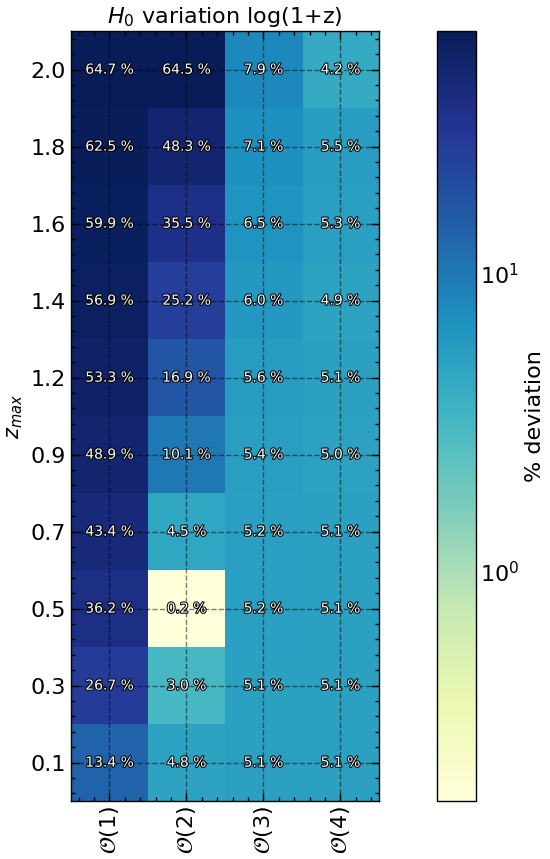

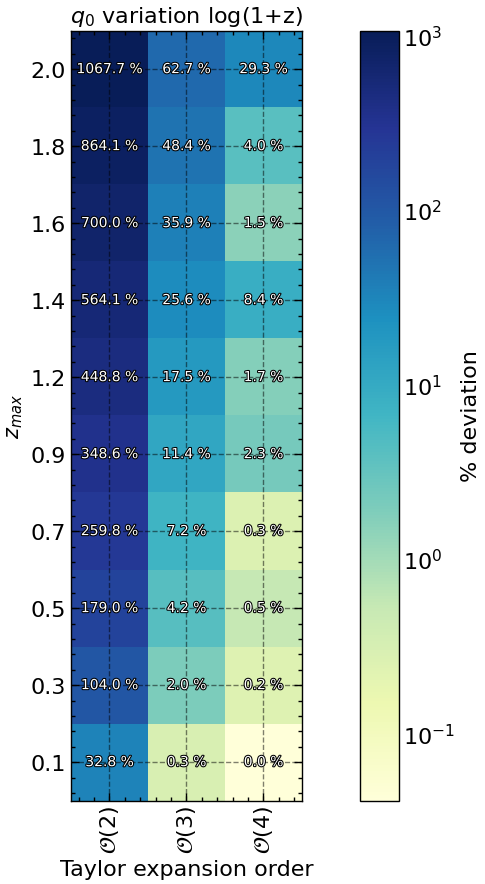

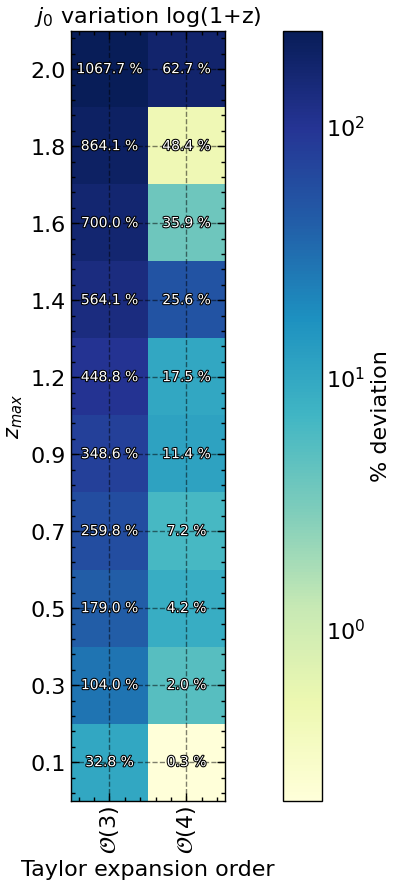

In [25]:
matrix_plot('log(1+z)',*value_extractor(kinematic_parameter_estimator('logz')))

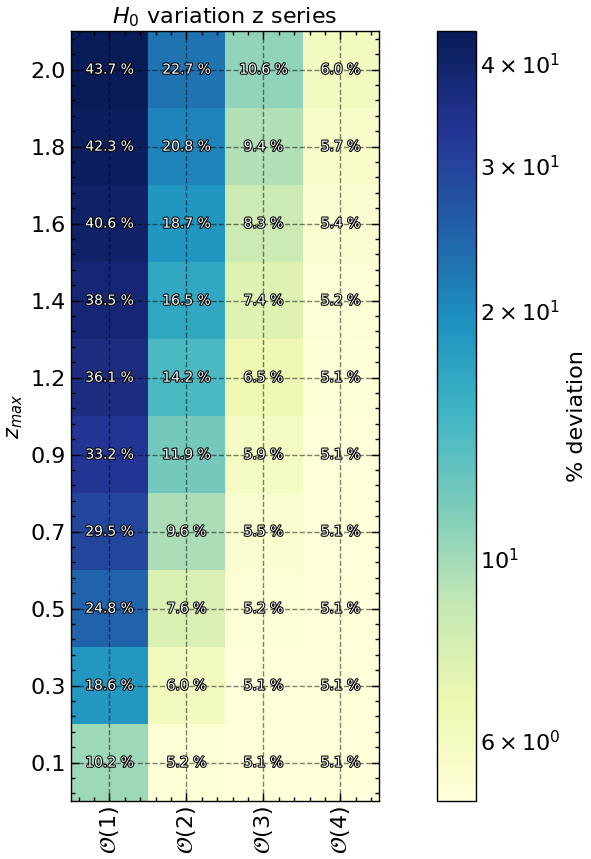

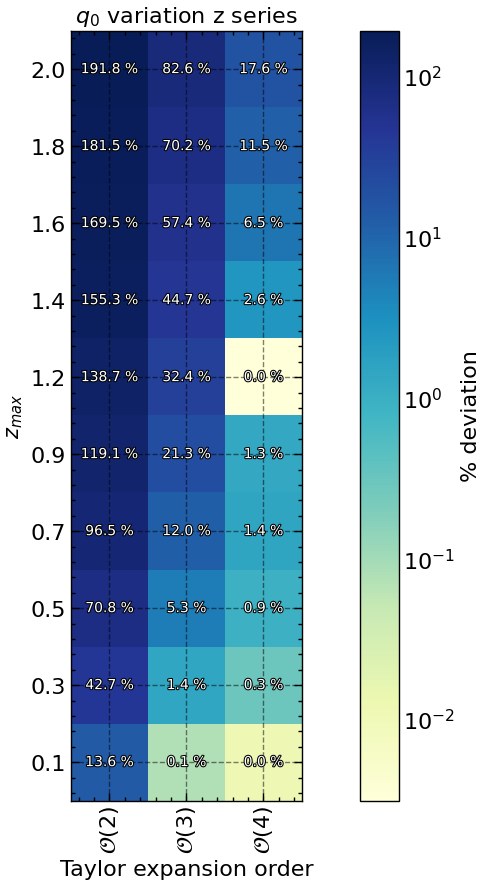

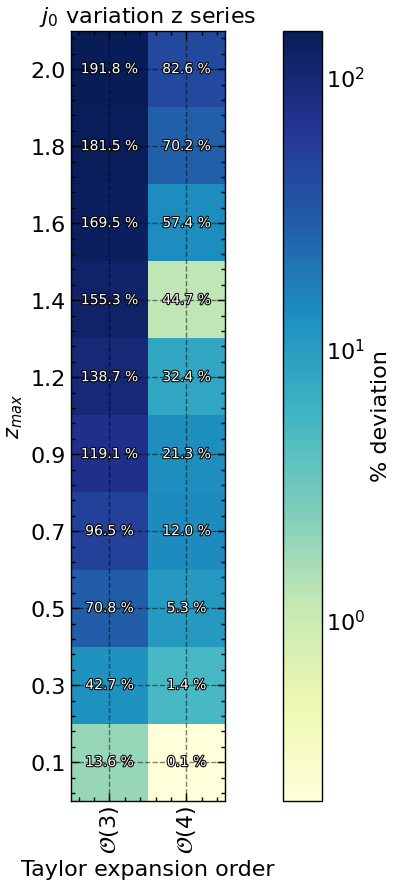

In [26]:
matrix_plot('z series',*value_extractor(kinematic_parameter_estimator('z_series')))

In [ ]:
df_z=pd.DataFrame(dct_z) #getting a dataframe of the results ,function name and success to do easy visualization 
##print(df) to see how df looks like 
#getting the H0 results 
H0_ar_z=[]
for i in df_z.Output:
    H0_ar_z.append(i[0])

q0_ar_z=[]
ix=0
for j in df_z.Output :
    if df_z.func.iloc[ix]!='z_series_1':
        q0_ar_z.append(j[1])
    ix+=1

#getting the j0 results 

j0_ar_z=[]
ix=0
for k in df_z.Output :
    if df_z.func.iloc[ix]!='z_series_1' and df_z.func.iloc[ix]!='z_series_2':
        j0_ar_z.append(k[2])
    ix+=1

    
##getting the error from true values 
H0_ar_z=np.reshape(H0_ar_z,(N,5)) ##first reshaping the arrays to get Nx5 matrix since we want our results in a matrix form
H0_err_z=abs((73.8-H0_ar_z)/73.8)*100
H0_err_z=np.flip(H0_err_z, axis=0)  ##flipping the array due to visualization
q0_ar_z=np.reshape(q0_ar_z,(N,4))
q0_err_z=abs((0.55+q0_ar_z)/0.55)*100
q0_err_z=np.flip(q0_err_z, axis=0)

j0_ar_z=np.reshape(j0_ar_z,(N,3))
j0_err_z=abs((1-j0_ar_z)/1)*100
j0_err_z=np.flip(j0_err_z, axis=0)


In [ ]:
plt.figure(figsize=(15,10))
plt.title('$H_0$ variation')
norm = mcolors.LogNorm(vmin=H0_err_z[H0_err_z > 0].min(), vmax=H0_err_z.max()) #W#creating color bar for log plot 

plt.imshow(H0_err_z,norm=norm,cmap=color_map) ##matrix plot 
y_ticks=[i for i in range(int(N))]
y_labels=np.round(np.linspace(ZMAX,0.1,int(N)),1)
x_ticks = [0, 1, 2, 3,4] 
plt.ylabel('$z_{max}$',fontsize=15)
x_labels = ['$\mathcal{O}(1)$', '$\mathcal{O}(2)$', '$\mathcal{O}(3)$', '$\mathcal{O}(4)$','$\mathcal{O}(5)$'] 
plt.xticks(x_ticks, x_labels, rotation ='vertical') 
plt.yticks(y_ticks, y_labels) 
plt.colorbar(label='% deviation')
## for annotating on the plot
for i in range(H0_err_z.shape[0]):
    for j in range(H0_err_z.shape[1]):
        text = plt.text(j, i, f'{H0_err_z[i, j]:.1f} %',
                       ha="center", va="center", color="white",path_effects=[path_effects.withStroke(linewidth=1.5, foreground="black")],fontsize=10)

plt.show()
_z_z_z_z_z_z_z


## j0_plot 
plt.figure(figsize=(15,10))
plt.title('$j_0$ variation')
norm = mcolors.LogNorm(vmin=j0_err[j0_err > 0].min(), vmax=j0_err.max())

plt.imshow(j0_err,cmap=color_map,norm=norm)
y_ticks=[i for i in range(int(N))]
y_labels=np.round(np.linspace(ZMAX,0.1,int(N)),1)
x_ticks = [0, 1, 2] 
plt.ylabel('$z_{max}$',fontsize=15)
plt.xlabel('Taylor expansion order')
x_labels = [  '$\mathcal{O}(3)$', '$\mathcal{O}(4)$','$\mathcal{O}(5)$'] 
plt.xticks(x_ticks, x_labels, rotation ='vertical') 
plt.yticks(y_ticks, y_labels) 
for i in range(j0_err.shape[0]):
    for j in range(j0_err.shape[1]):
        text = plt.text(j, i, f'{q0_err[i, j]:.1f} %',
                       ha="center", va="center", color="white",path_effects=[path_effects.withStroke(linewidth=1.5, foreground="black")],fontsize=10)

#v = np.linspace(0, 100, 10, endpoint=True)

plt.colorbar(label='% deviation')
plt.show()


## j0_plot 
plt.figure(figsize=(15,10))
plt.title('$j_0$ variation')
norm = mcolors.LogNorm(vmin=j0_err[j0_err > 0].min(), vmax=j0_err.max())

plt.imshow(j0_err,cmap=color_map,norm=norm)
y_ticks=[i for i in range(int(N))]
y_labels=np.round(np.linspace(ZMAX,0.1,int(N)),1)
x_ticks = [0, 1, 2] 
plt.ylabel('$z_{max}$',fontsize=15)
plt.xlabel('Taylor expansion order')
x_labels = [  '$\mathcal{O}(3)$', '$\mathcal{O}(4)$','$\mathcal{O}(5)$'] 
plt.xticks(x_ticks, x_labels, rotation ='vertical') 
plt.yticks(y_ticks, y_labels) 
for i in range(j0_err.shape[0]):
    for j in range(j0_err.shape[1]):
        text = plt.text(j, i, f'{q0_err[i, j]:.1f} %',
                       ha="center", va="center", color="white",path_effects=[path_effects.withStroke(linewidth=1.5, foreground="black")],fontsize=10)

#v = np.linspace(0, 100, 10, endpoint=True)

plt.colorbar(label='% deviation')
plt.show()

In [ ]:
## q0_plot 
plt.figure(figsize=(15,10))
plt.title('$q_0$ variation')
norm = mcolors.LogNorm(vmin=q0_err_z[q0_err_z > 0].min(), vmax=q0_err_z.max())

plt.imshow(q0_err_z,cmap=color_map,norm=norm)
y_ticks=[i for i in range(int(N))]
y_labels=np.round(np.linspace(ZMAX,0.1,int(N)),1)
x_ticks = [0, 1, 2, 3] 
plt.ylabel('$z_{max}$',fontsize=15)
plt.xlabel('Taylor expansion order')
x_labels = [ '$\mathcal{O}(2)$', '$\mathcal{O}(3)$', '$\mathcal{O}(4)$','$\mathcal{O}(5)$'] 
plt.xticks(x_ticks, x_labels, rotation ='vertical') 
plt.yticks(y_ticks, y_labels) 
for i in range(q0_err_z.shape[0]):
    for j in range(q0_err_z.shape[1]):
        text = plt.text(j, i, f'{q0_err_z[i, j]:.1f} %',
                       ha="center", va="center", color="white",path_effects=[path_effects.withStroke(linewidth=1.5, foreground="black")],fontsize=10)

#v = np.linspace(0, 100, 10, endpoint=True)

plt.colorbar(label='% deviation')
plt.show()


In [ ]:

## j0_plot 
plt.figure(figsize=(15,10))
plt.title('$j_0$ variation')
norm = mcolors.LogNorm(vmin=j0_err[j0_err > 0].min(), vmax=j0_err.max())

plt.imshow(j0_err,cmap=color_map,norm=norm)
y_ticks=[i for i in range(int(N))]
y_labels=np.round(np.linspace(ZMAX,0.1,int(N)),1)
x_ticks = [0, 1, 2] 
plt.ylabel('$z_{max}$',fontsize=15)
plt.xlabel('Taylor expansion order')
x_labels = [  '$\mathcal{O}(3)$', '$\mathcal{O}(4)$','$\mathcal{O}(5)$'] 
plt.xticks(x_ticks, x_labels, rotation ='vertical') 
plt.yticks(y_ticks, y_labels) 
for i in range(j0_err.shape[0]):
    for j in range(j0_err.shape[1]):
        text = plt.text(j, i, f'{q0_err[i, j]:.1f} %',
                       ha="center", va="center", color="white",path_effects=[path_effects.withStroke(linewidth=1.5, foreground="black")],fontsize=10)

#v = np.linspace(0, 100, 10, endpoint=True)

plt.colorbar(label='% deviation')
plt.show()
